In [1]:
#General
import re
import sys
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from bios    import read
from os.path import isfile
from copy    import deepcopy
from time    import time
from tqdm    import tqdm
from getdist import plots

from scipy.interpolate import interp1d
from scipy.stats       import multivariate_normal
from itertools         import repeat

from getdist import plots,loadMCSamples,MCSamples
from getdist.gaussian_mixtures import GaussianND

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

print('WTF?')

WTF?


In [2]:
fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'ns': 0.96,
            'As': 2.12605e-09,
            'H0': 67.,
            'w': -1.,
            'wa': 0.,
            'tau': 0.05,
            'mnu': 0.06,
            'a0': - 0.007589,
            'a1' :  0.002008,
            'a2' : - 0.004127,
            'a3' :  0.002918,
            'a4' : -0.0006784,
            'omegab': 0.05,
            'sigma8': 0.84,
            'omegam' : 0.31,
            #'A_IA': 1.72,
            #'eta_IA': -0.41,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292
           }
fiducial['logA'] = np.log(fiducial['As']*1.e+10)

plot_pars = ['ombh2','omch2','ns','logA','H0']

In [3]:
results = {#r'$\Lambda$CDM (MH)': {'root': '/Users/chiaradeleo/Desktop/chains/3x2pt_LCDM_MH',
           #                       'sampler': 'MH',
           #                       'temperature': 1,
           #                       'Nchains': 4,
           #                       'color': 'blue',
           #                       'filled': True},
           #r'$\Lambda$CDM (Fisher fourth)': {'root': './chains/LCDM_fisher_fourth_full',
           #                                      'sampler': 'Fisher',
           #                                      'color': 'purple',
           #                                      'filled': True},
           #r'$\Lambda$CDM (Fisher)': {'root': './chains/LCDM_fisher_second_full',
           #                                      'sampler': 'Fisher',
           #                                      'color': 'cyan',
           #                                      'filled': True},
           r'$\Lambda$CDM fixed nuis (Fisher with GW)': {'root': './chains/LCDM_GW_fisher_second',
                                                 'sampler': 'Fisher',
                                                 'color': red,
                                                 'filled': True},
           r'$\Lambda$CDM fixed nuis (Fisher)': {'root': './chains/LCDM_fisher_fourth',
                                                 'sampler': 'Fisher',
                                                 'color': yellow,
                                                 'filled': True},
          }

In [4]:
def analyze_results(name,info):
    analysis = deepcopy(info)
    
    print('')
    print('\x1b[1;31m Analyzing {} \x1b[0m'.format(name))
    
    if info['sampler'] == 'MH':
        sample = loadMCSamples(info['root'], settings={'ignore_rows': 0.3})
        sample.cool(info['temperature'])
    
        if info['Nchains']>1:
            print('R-1({}) with {:.0f}% of points ignored = {:.3f}'.format(name,30,
                                                                           sample.getGelmanRubin()))
        else:
            print('Single chain, no R-1 computed. Trust Cobaya and hope for the best')
    elif info['sampler'] == 'Fisher':
        fisher = pd.read_csv(info['root']+'_matrix.txt',header=0,sep='\s+')
        fisher.index = fisher.columns
        fisher_info = np.load(info['root']+'_info.npy',allow_pickle=True).item()
        print(fisher)
        plt.figure()
        plt.title(name)
        sb.heatmap(fisher)
        
        sample = GaussianND([fisher_info[par]['fiducial'] for par in fisher.columns], 
                            np.linalg.inv(fisher.values),
                            names=fisher.columns, 
                            labels=[fisher_info[par]['latex'] for par in fisher.columns]).MCSamples(10000)
    else:
        sys.exit('Unknown sampler: {}'.format(info['sampler']))
        
        
        
    analysis['MCsamples'] = sample
    analysis['bounds']    = sample.getTable(limit=1).tableTex()
    
    all_pars     = sample.getParamNames().list()
    labels       = sample.getParamNames().labels()
    primary_pars = sample.getParamNames().getRunningNames()


    analysis['means'] = {par:val for par,val in zip(all_pars,sample.getMeans())}

    print(analysis['bounds'])
                               
    all_pars = sample.getParamNames().list()
                               
    analysis['Sampled points']         = pd.DataFrame(sample.makeSingleSamples(),columns=all_pars)
    analysis['Sampled points']['Case'] = name
                    
    return analysis


 Analyzing $\Lambda$CDM fixed nuis (Fisher with GW) 
              ombh2         omch2            H0            ns          logA
ombh2  1.898627e+09 -2.301853e+09 -1.024176e+07 -1.016086e+07 -2.219184e+08
omch2 -2.300099e+09  3.389766e+09  2.332279e+07 -1.062654e+08  3.653746e+08
H0    -1.020560e+07  2.327936e+07  3.481126e+05 -3.282038e+06  3.521848e+06
ns    -1.048113e+07 -1.056816e+08 -3.283002e+06  3.871420e+07 -2.516338e+07
logA  -2.216353e+08  3.650833e+08  3.525727e+06 -2.519977e+07  4.496926e+07
Removed no burn in


/Users/chiaradeleo/myenv/lib/python3.9/site-packages/getdist/gaussian_mixtures.py:66: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  v = random_state.multivariate_normal(mean, cov, size=num)
/Users/chiaradeleo/myenv/lib/python3.9/site-packages/getdist/gaussian_mixtures.py:66: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  v = random_state.multivariate_normal(mean, cov, size=num)


\begin{tabular} { l  c}

 Parameter &  68\% limits\\
\hline
{\boldmath$\Omega_{\rm b}\,h^2$} & $0.02244\pm 0.00028        $\\

{\boldmath$\Omega_{\rm c}\,h^2$} & $0.12057\pm 0.00046        $\\

{\boldmath$H_0            $} & $67.000\pm 0.025           $\\

{\boldmath$n_{\rm s}      $} & $0.9599\pm 0.0027          $\\

{\boldmath$\log{10^{10}\,A_{\rm s}}$} & $3.0567\pm 0.0076          $\\
\hline
\end{tabular}

 Analyzing $\Lambda$CDM fixed nuis (Fisher) 
              ombh2         omch2            H0            ns          logA
ombh2  7.747294e+09 -7.819254e+09  3.353320e+06 -5.117803e+08 -5.630552e+08
omch2 -7.819303e+09  8.243606e+09 -4.212960e+06  5.268923e+08  5.814769e+08
H0     3.353357e+06 -4.212939e+06  3.454756e+03 -2.366584e+05 -2.742454e+05
ns    -5.117707e+08  5.268776e+08 -2.366443e+05  3.710849e+07  3.737865e+07
logA  -5.630652e+08  5.814848e+08 -2.742531e+05  3.737989e+07  4.149564e+07
Removed no burn in
\begin{tabular} { l  c}

 Parameter &  68\% limits\\
\hline
{\boldm

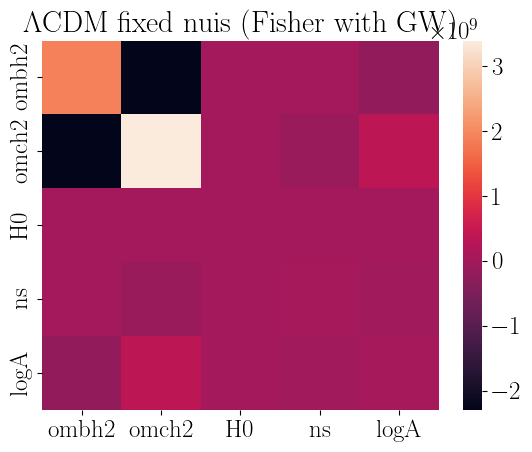

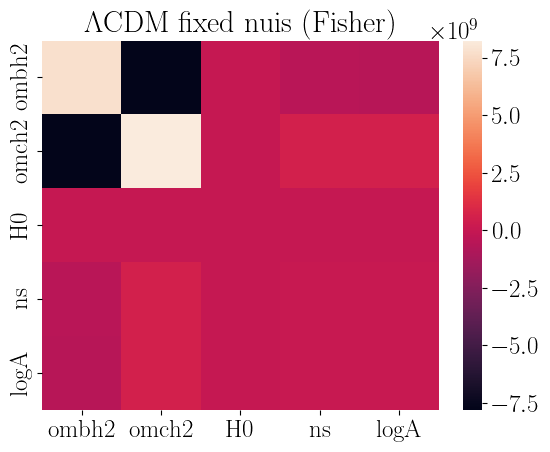

In [5]:
analyzed_results = {name: analyze_results(name,resdict) for name,resdict in results.items()}

<Figure size 640x480 with 0 Axes>

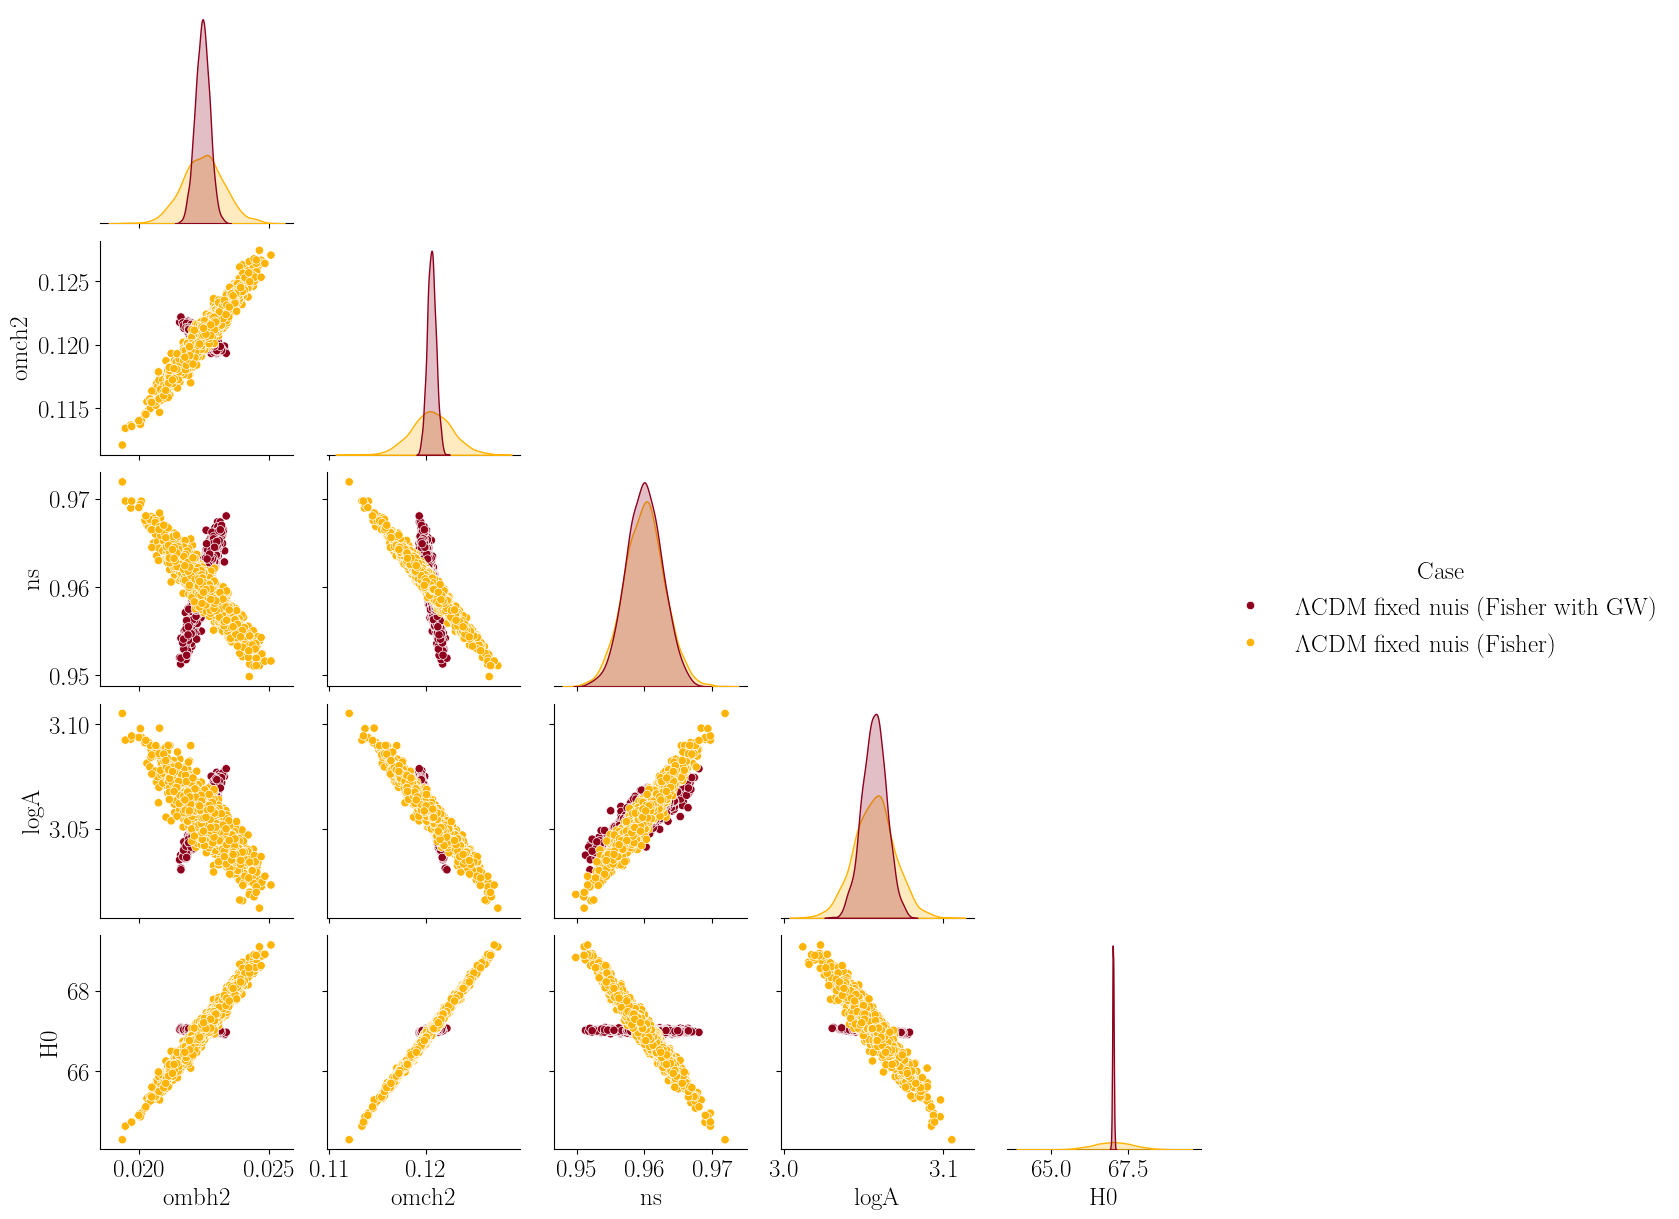

In [6]:
all_results = pd.concat([result['Sampled points'] for result in analyzed_results.values()])

plt.figure()
pplot = sb.pairplot(all_results,vars=plot_pars,hue='Case',
                    palette=[result['color'] for result in results.values()],
                    diag_kind='kde',kind='scatter',corner=True);
plt.savefig('Fisher_MCMC_points.pdf',dpi=500,bbox_inches='tight');

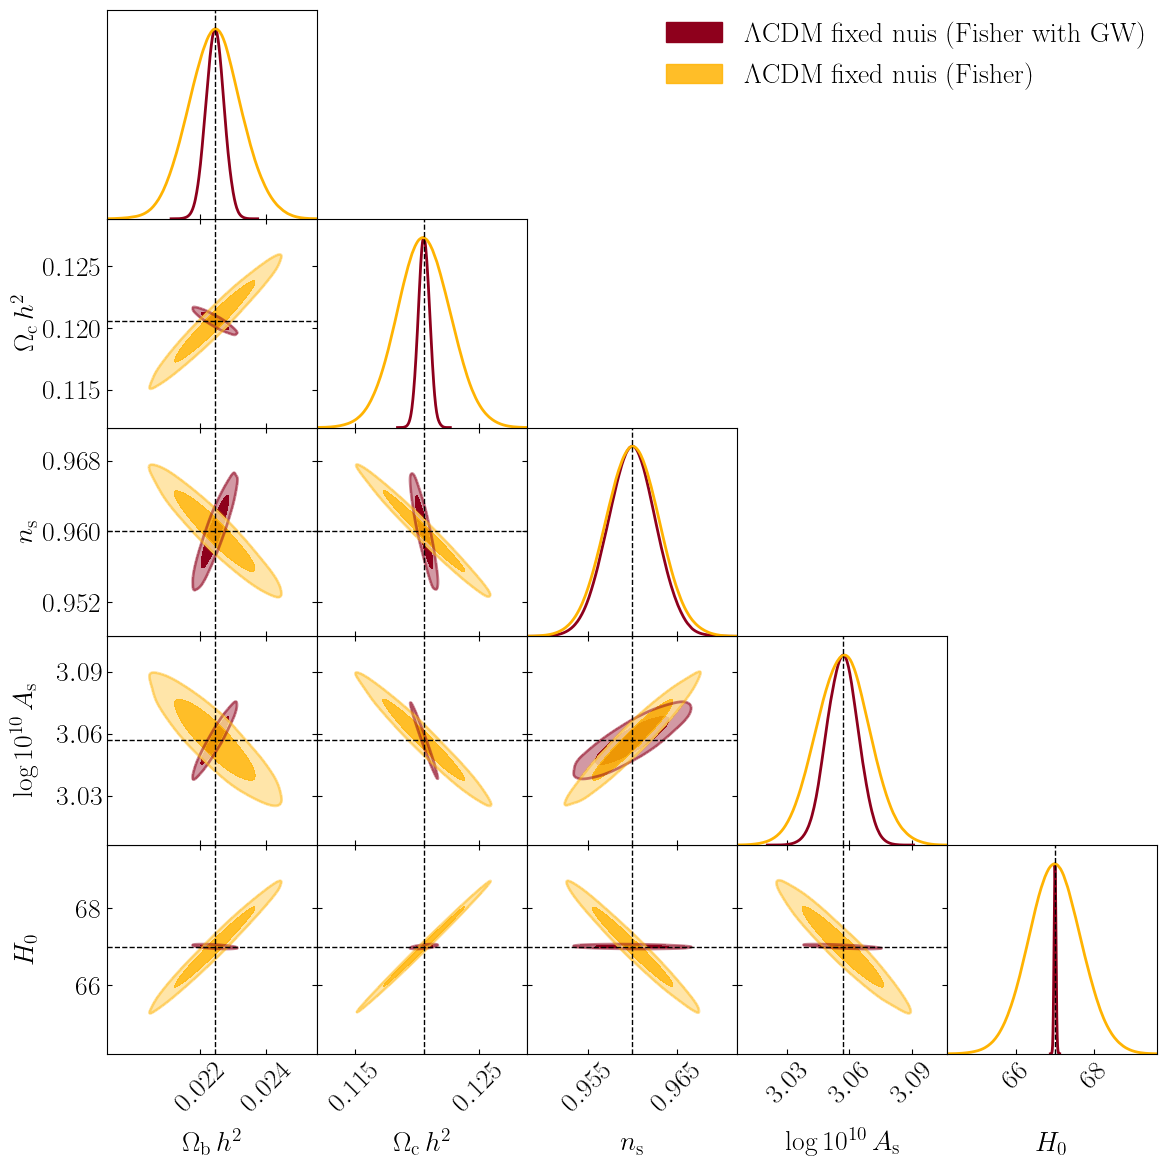

In [7]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)
g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot([result['MCsamples'] for result in analyzed_results.values()], plot_pars,
    filled=[result['filled'] for result in analyzed_results.values()],
    legend_loc='upper right',
    legend_labels=[result for result in analyzed_results.keys()],
    contour_colors=[result['color'] for result in analyzed_results.values()],
    contour_lws=2,
    markers={k:v for k,v in fiducial.items()})    
g.fig.align_ylabels()
g.fig.align_xlabels();
plt.savefig('Fisher_GW.pdf',dpi=500,bbox_inches='tight');